This scheme works! It was derived using the pullback metric in the same manner as a geodesic using the pullback onto $I$ through the curve $\psi: I \to S$ but defines the velocity of the curve $\psi^\prime$ on a $n$-dimensionnal real vector space over the input-state manifold so it perfectly describes evolution of the system as a function of the state position and the control inputs.

This works even with nonzero control inputs so it seems to hold generally. However note that the exact solution is not known given a matrix developed along the way is invertible and so the pseudoinverse is needed.

Refer to notes for additional information (this is just for testing purposes).

In [91]:
import sympy as sp
import sympy.diffgeom as dg

import numpy as np

import matplotlib.pyplot as plt
import scipy.integrate as sint

import itertools

In [94]:
n = 5  # states
m = 2  # inputs

state_input_mfld = dg.Manifold(r"Q \times U", n + m)
state_input_mfld_patch = dg.Patch("P", state_input_mfld)

x, y, theta, v, omega, u_f, u_t = sp.symbols(r"x,y,\theta,v,\omega,u_f,u_t", real=True)

state_input_mfld_coords = dg.CoordSystem(
    "StateInput", state_input_mfld_patch, (x, y, theta, v, omega, u_f, u_t)
)

(x_sc, y_sc, theta_sc, v_sc, omega_sc, u_f_sc, u_t_sc) = (
    state_input_mfld_coords.base_scalars()
)

(x_vec, y_vec, theta_vec, v_vec, omega_vec, u_f_vec, u_t_vec) = (
    state_input_mfld_coords.base_vectors()
)

q_vecs = (x_vec, y_vec, theta_vec, v_vec, omega_vec)
u_vecs = (u_f_vec, u_t_vec)

print(f"q basis vecs: {q_vecs}")
print(f"u basis vecs: {u_vecs}")

# vector field defined on the real n-dimensional vector space on top of the
# input-state manifold (real vector bundle on top of fibre bundle of Q and U)
f = (
    v_sc * sp.cos(theta_sc) * x_vec
    + v_sc * sp.sin(theta_sc) * y_vec
    + omega_sc * theta_vec
    + u_f * v_vec
    + u_t * omega_vec
)
display(f)

q basis vecs: (e_x, e_y, e_\theta, e_v, e_\omega)
u basis vecs: (e_u_f, e_u_t)


u_f*e_v + u_t*e_\omega + sin(\theta)*v*e_y + cos(\theta)*v*e_x + \omega*e_\theta

In [135]:
def gen_conn_coeffs(f_curve, q_vecs, u_vecs):
    # separate f into the coefficients of the vector space basis
    f_coeffs = [f_curve.coeff(v) for v in q_vecs]
    f_diag_inv: sp.Matrix = sp.Matrix.diag(f_coeffs).inv()

    # evaluates the jacobian (have to do this manually as sp.diff does not work
    # properly due to the usage of the differential geometry expressions)
    n = len(q_vecs)
    m = len(u_vecs)

    qu_vecs = list(itertools.chain(q_vecs, u_vecs))

    d: sp.Matrix = sp.Matrix(f_coeffs)

    conn_coeffs = sp.MutableDenseNDimArray.zeros(n, n, n + m)
    for k in range(n):

        bk: sp.Matrix = sp.MutableMatrix.zeros(n + m, 1)
        for i in range(n + m):
            bk[i] = qu_vecs[i](f_coeffs[k])

        ck: sp.Matrix = -(d @ d.T).pinv() @ d @ bk.T

        # WAIT A GOD DAMN MINUTE, THESE EQUATIONS ARE THE EXACT SAME FOR EACH K
        #
        # b = sp.MutableMatrix.zeros(n, n + m)
        # for i in range(n):
        #     for j in range(n + m):
        #         # uses the basis vector to differentiate
        #         b[i, j] = qu_vecs[j](f_coeffs[i])
        #
        # ck = -f_diag_inv @ b
        #
        # print("Testing")
        # for j in range(n):
        #     for i in range(n + m):
        #         a = qu_vecs[i](f_coeffs[j]) + f_coeffs[j] * ck[j, i]
        #         print(f"a: {a}")
        # return

        conn_coeffs[k, :, :] = ck

    return conn_coeffs


# sets up a function that can be run to evaluate the current connection
# coefficients as a function of the position on the input-state manfiold

conn_coeffs = gen_conn_coeffs(f, q_vecs, u_vecs).applyfunc(
    lambda elem: elem.subs(x_sc, x)
    .subs(y_sc, y)
    .subs(theta_sc, theta)
    .subs(v_sc, v)
    .subs(omega_sc, omega)
    .nsimplify()
    .simplify(),
)


def eval_conn_coeffs(q_coords, u_coords):
    vals = np.array(
        [
            sp.lambdify((x, y, theta, v, omega, u_f, u_t), expr)(
                *[*q_coords, *u_coords]
            )
            for expr in list(conn_coeffs)
        ]
    )
    return vals.reshape(conn_coeffs.shape)


conn_coeffs

[[[0, 0, v**2*sin(2*\theta)/(2*(\omega**2 + u_f**2 + u_t**2 + v**2)), -v*cos(\theta)**2/(\omega**2 + u_f**2 + u_t**2 + v**2), 0, 0, 0], [0, 0, v**2*sin(\theta)**2/(\omega**2 + u_f**2 + u_t**2 + v**2), -v*sin(2*\theta)/(2*\omega**2 + 2*u_f**2 + 2*u_t**2 + 2*v**2), 0, 0, 0], [0, 0, \omega*v*sin(\theta)/(\omega**2 + u_f**2 + u_t**2 + v**2), -\omega*cos(\theta)/(\omega**2 + u_f**2 + u_t**2 + v**2), 0, 0, 0], [0, 0, u_f*v*sin(\theta)/(\omega**2 + u_f**2 + u_t**2 + v**2), -u_f*cos(\theta)/(\omega**2 + u_f**2 + u_t**2 + v**2), 0, 0, 0], [0, 0, u_t*v*sin(\theta)/(\omega**2 + u_f**2 + u_t**2 + v**2), -u_t*cos(\theta)/(\omega**2 + u_f**2 + u_t**2 + v**2), 0, 0, 0]], [[0, 0, -v**2*cos(\theta)**2/(\omega**2 + u_f**2 + u_t**2 + v**2), -v*sin(2*\theta)/(2*\omega**2 + 2*u_f**2 + 2*u_t**2 + 2*v**2), 0, 0, 0], [0, 0, -v**2*sin(2*\theta)/(2*\omega**2 + 2*u_f**2 + 2*u_t**2 + 2*v**2), -v*sin(\theta)**2/(\omega**2 + u_f**2 + u_t**2 + v**2), 0, 0, 0], [0, 0, -\omega*v*cos(\theta)/(\omega**2 + u_f**2 + u_t**

In [145]:
T_FINAL = 10.0
T_DIVISIONS = 1000

t = np.linspace(0, T_FINAL, T_DIVISIONS)

# solve time-varying system via an integral curve

X_0 = np.array([0.3, 0.6, -0.1, 1.0, 0.7])
U_0 = np.array([0.1, -0.1])


def unicycle_model_f(t, y):
    x, y, theta, v, omega = y
    return np.array([v * np.cos(theta), v * np.sin(theta), omega, U_0[0], U_0[1]])


curve_result = sint.solve_ivp(unicycle_model_f, [0.0, T_FINAL], X_0, t_eval=t[1:-1])
curve_path = curve_result.y.T  # each time sample on rows

# solve time-varying system via the connection coefficients

QU_POS_0 = np.concat([X_0, U_0])
QU_VEL_0 = np.concat([unicycle_model_f(0.0, X_0), np.zeros((2,))])
Y0 = np.concat([QU_POS_0, QU_VEL_0])

EPS = 1e-12


def vbundle_geodesic_fn(t, y):
    # note that for this "geodesic" there are 2 velocities in play here; one is
    # the velocity within the n-dimensional vector space over the input-state
    # manifold and the other within the tangent space over the input-state
    # manifold (which due to the tangent bundle isomorphism shares the first
    # n components of each vector)

    qu_pos = y[: (n + m)] + EPS
    qu_vel = y[(n + m) :] + EPS

    vb_vel, tb_vel = (qu_vel[:n], qu_vel)
    q_pos, u_pos = (qu_pos[:n], qu_pos[n:])

    conn_coeffs = eval_conn_coeffs(q_pos, u_pos)

    # for our purposes this curve exists only in the vector space so there  is
    # no acceleration of the curve along coordinates that pertain to the inputs
    dot_tb_pos = qu_vel
    dot_tb_vel = np.zeros((n + m,))
    for k in range(n):
        for i in range(n):
            for j in range(n + m):
                dot_tb_vel[k] += -vb_vel[i] * tb_vel[j] * conn_coeffs[k, i, j]

    return np.concat((dot_tb_pos, dot_tb_vel))


geodesic_result = sint.solve_ivp(
    vbundle_geodesic_fn, [0.0, T_FINAL], Y0, t_eval=t[1:-1], method=sint.BDF
)
geodesic_path = geodesic_result.y.T  # each time sample on rows

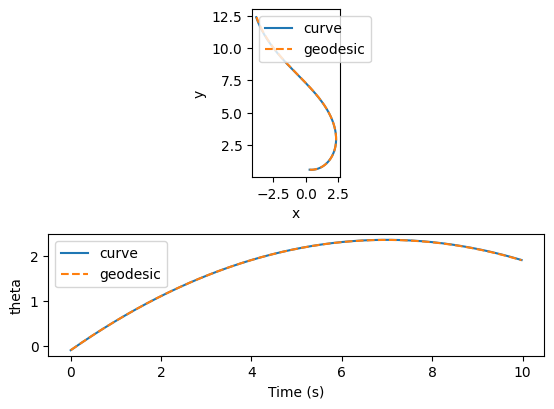

In [146]:
# generate plots showing the similarity
fig, (ax1, ax2) = plt.subplots((2))

ax1.plot(curve_path[:, 0], curve_path[:, 1], label="curve")
ax1.plot(geodesic_path[:, 0], geodesic_path[:, 1], "--", label="geodesic")
ax1.set_aspect("equal")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

ax2.plot(t[: curve_path.shape[0]], curve_path[:, 2], label="curve")
ax2.plot(t[: geodesic_path.shape[0]], geodesic_path[:, 2], "--", label="geodesic")
ax2.set_aspect("equal")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("theta")

ax1.legend()
ax2.legend()